In [1]:
!pip install h5py kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'figshare-brain-tumor-dataset' dataset.
Dataset path: /kaggle/input/figshare-brain-tumor-dataset


In [3]:
import tensorflow as tf
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import cv2
import h5py
import scipy.io
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import preprocess_input

In [4]:
data_path = os.path.join(path, "dataset", "data")

all_files = [
    os.path.join(data_path, f)
    for f in os.listdir(data_path)
    if f.endswith(".mat")
]

print("Total files:", len(all_files))

Total files: 3064


In [5]:
train_files, val_files = train_test_split(
    all_files,
    test_size=0.2,
    random_state=42
)

In [6]:
file_path = os.path.join(path, "dataset/data/1576.mat")

data = h5py.File(file_path, 'r')

print(list(data.keys()))

['cjdata']


In [7]:
cjdata = data['cjdata']
print(list(cjdata.keys()))

['PID', 'image', 'label', 'tumorBorder', 'tumorMask']


In [8]:
image = np.array(cjdata['image'])
label = np.array(cjdata['label'])[0][0]

print("Label:", label)
print("Image shape:", image.shape)

Label: 3.0
Image shape: (512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

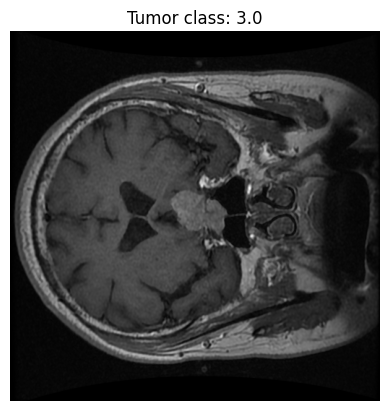

In [9]:
plt.imshow(image, cmap="gray")
plt.title("Tumor class: " + str(label))
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

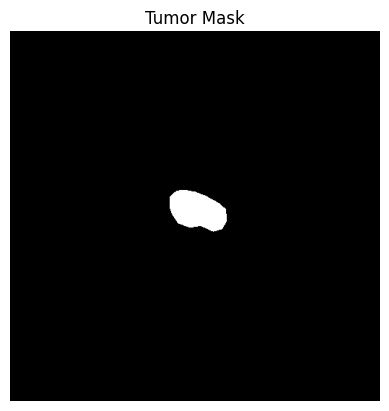

In [10]:
mask = np.array(cjdata['tumorMask'])

plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

In [11]:
def data_generator(file_list, batch_size=32, augment=False):

    if augment:
        datagen = ImageDataGenerator(
            rotation_range=10,
            zoom_range=0.1,
            width_shift_range=0.05,
            height_shift_range=0.05
        )
    else:
        datagen = ImageDataGenerator()

    while True:

        np.random.shuffle(file_list)

        for i in range(0, len(file_list), batch_size):

            batch_files = file_list[i:i+batch_size]

            images = []
            labels = []

            for file in batch_files:

                with h5py.File(file, 'r') as data:

                    cjdata = data['cjdata']

                    img = np.array(cjdata['image'])

                    img = cv2.resize(img, (224,224))

                    # grayscale → RGB
                    img = np.repeat(img[..., np.newaxis], 3, axis=-1)

                    label = np.array(cjdata['label'])[0][0] - 1

                    images.append(img)
                    labels.append(label)

            X = np.array(images, dtype=np.float32)
            y = np.array(labels)

            X = preprocess_input(X)

            if augment:
                X, y = next(datagen.flow(X, y, batch_size=len(X), shuffle=False))

            yield X, y

In [12]:
batch_size = 32

train_gen = data_generator(train_files, batch_size=batch_size, augment=True)
val_gen = data_generator(val_files, batch_size=batch_size, augment=False)

In [13]:
# base_model = VGG16(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(224,224,3)
# )

In [14]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

output = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [16]:
for layer in base_model.layers:
    layer.trainable = True

In [17]:
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
steps_per_epoch = len(train_files) // batch_size
validation_steps = len(val_files) // batch_size

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=4
)

Epoch 1/4
76/76 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.8047 - loss: 0.4972 - val_accuracy: 0.7714 - val_loss: 0.5891
Epoch 2/4
76/76 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9202 - loss: 0.2169 - val_accuracy: 0.9112 - val_loss: 0.2318
Epoch 3/4
76/76 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9405 - loss: 0.1579 - val_accuracy: 0.9276 - val_loss: 0.2131
Epoch 4/4
76/76 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9620 - loss: 0.0992 - val_accuracy: 0.9294 - val_loss: 0.2099


In [19]:
model.save("brain_tumor_efficientnet_model.keras")

# GRAD CAM

In [20]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [21]:
X_batch, y_batch = next(val_gen)

In [22]:
img = X_batch[8]

img_array = np.expand_dims(img, axis=0)

In [23]:
np.argmax(model.predict(img_array))

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


np.int64(2)

In [24]:
heatmap = make_gradcam_heatmap(img_array, model, "top_conv")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [25]:
img_display = img.copy()

img_display -= img_display.min()
img_display /= img_display.max()
img_display *= 255
img_display = img_display.astype("uint8")

heatmap = cv2.resize(heatmap, (224,224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(
    img_display.astype("uint8"),
    0.7,
    heatmap,
    0.3,
    0
)

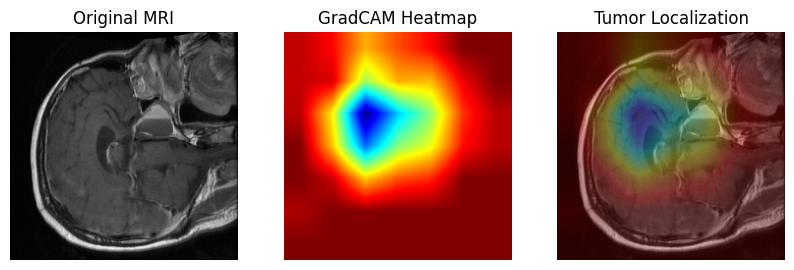

In [26]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original MRI")
plt.imshow(img_display.astype("uint8"))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("GradCAM Heatmap")
plt.imshow(heatmap)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Tumor Localization")
plt.imshow(superimposed.astype("uint8"))
plt.axis("off")

plt.show()

# GUIDED GRAD CAM

In [27]:
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

In [28]:
def build_guided_model(model):

    guided_model = tf.keras.models.clone_model(model)
    guided_model.set_weights(model.get_weights())

    for layer in guided_model.layers:
        if hasattr(layer, "activation"):
            if layer.activation == tf.keras.activations.relu:
                layer.activation = guided_relu

    return guided_model

In [29]:
def guided_backprop(guided_model, img_array):

    img_array = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_array)
        preds = guided_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, img_array)

    return grads[0].numpy()

In [30]:
guided_model = build_guided_model(model)

gb = guided_backprop(guided_model, img_array)

cam = cv2.resize(heatmap, (224,224))

# normalize heatmap
cam = cam / cam.max()

# expand dimension
cam = np.expand_dims(cam, axis=-1)
cam = np.squeeze(cam)
guided_gradcam = gb * cam

In [31]:
guided_gradcam -= guided_gradcam.min()
guided_gradcam /= guided_gradcam.max()

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

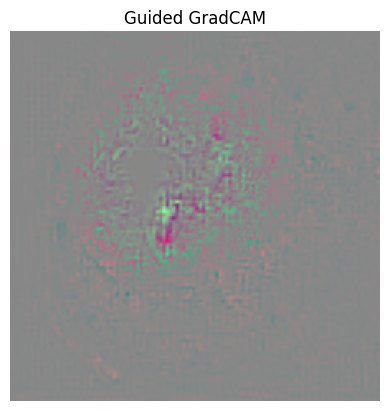

In [32]:
plt.imshow(guided_gradcam)
plt.title("Guided GradCAM")
plt.axis("off")

STILL WORKING .....
